# 04 — Business Impact

Cross-source price-vs-nutrition, the category business-risk framework, and the consumer-response scenario — the 'so what' for an FMCG audience.

In [1]:
import sys, json
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FINAL = ROOT / 'data' / 'final'
CLEAN = ROOT / 'data' / 'cleaned'
RAW = ROOT / 'data' / 'raw'
metrics = json.loads((ROOT / 'reports' / 'computed_metrics.json').read_text())
pd.set_option('display.max_columns', 40)


## Q5 — Does price buy nutrition? (Indian prices × nutrition)

Spearman(price, badness) = 0.338 | p = 0.0981 | n = 25


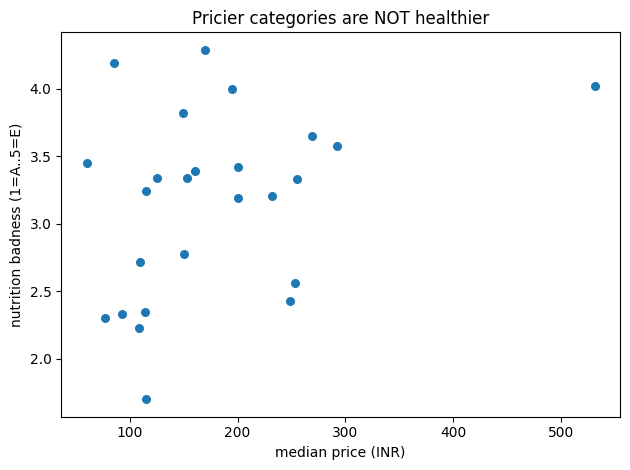

In [2]:
price = pd.read_csv(FINAL / 'price_vs_nutrition_category.csv')
q5 = metrics['q5_price_nutrition']
print('Spearman(price, badness) =', q5['spearman_price_vs_badness'],
      '| p =', q5['spearman_p_value'], '| n =', q5['n_categories_matched'])
ax = price.plot.scatter(x='median_price_inr', y='avg_score', s=30)
ax.set_xlabel('median price (INR)'); ax.set_ylabel('nutrition badness (1=A..5=E)')
ax.set_title('Pricier categories are NOT healthier'); plt.tight_layout(); plt.show()

## Q6 — Category business risk
Equal-weight blend of nutrition exposure, consumer sensitivity and commercial importance (Indian assortment share).

In [3]:
risk = pd.read_csv(FINAL / 'category_business_risk.csv').sort_values('business_risk', ascending=False)
risk.head(10)

,category,de_pct,nutrition_exposure,consumer_sensitivity,commercial_importance,business_risk,business_risk_alt
0,Chocolate & Confectionery,85.78,0.858,1.0,1.000,0.953,0.929
1,"Biscuits, Cookies & Wafers",81.63,0.816,0.9,0.457,0.724,0.769
2,"Chips, Crisps & Salty Snacks",51.82,0.518,1.0,0.487,0.668,0.656
3,"Spreads, Jam, Honey & Syrups",64.28,0.643,0.7,0.445,0.596,0.620
4,"Cakes, Pastries & Sweet Bakery",70.34,0.703,0.9,0.148,0.584,0.651
5,"Sauces, Ketchup & Condiments",48.47,0.485,0.6,0.557,0.547,0.534
6,Ice Cream & Frozen Desserts,62.27,0.623,0.9,0.057,0.526,0.593
7,"Tea, Coffee & Hot Drink Mixes",48.65,0.486,0.6,0.462,0.516,0.516
8,Sugar-Sweetened Beverages,44.18,0.442,1.0,0.103,0.515,0.542
9,Cheese,74.64,0.746,0.5,0.278,0.508,0.579


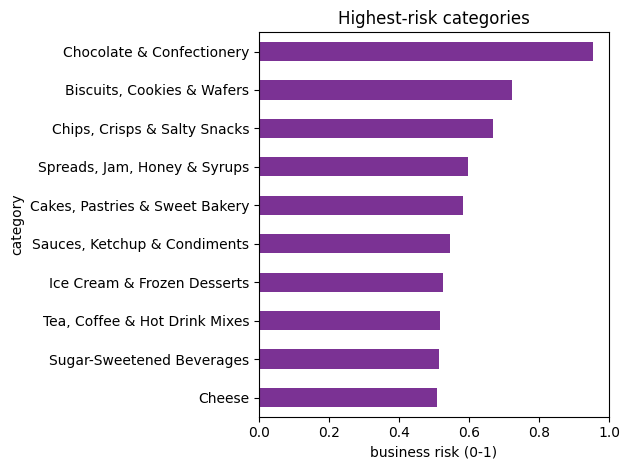

In [4]:
r = risk.head(10).set_index('category')['business_risk'].sort_values()
ax = r.plot(kind='barh', color='#7b3294'); ax.set_xlabel('business risk (0-1)')
ax.set_title('Highest-risk categories'); plt.tight_layout(); plt.show()

## Scenario — at-risk D/E SKUs by scenario

scenario
Low          2440.0
Moderate     6098.0
High        12196.0
Name: at_risk_de_skus, dtype: float64


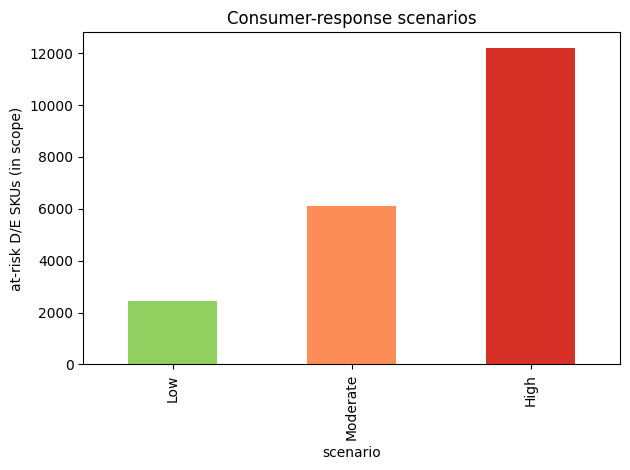

In [5]:
scen = pd.read_csv(FINAL / 'scenario_results.csv')
tot = scen.groupby('scenario')['at_risk_de_skus'].sum().reindex(['Low','Moderate','High'])
print(tot.round(0))
ax = tot.plot(kind='bar', color=['#91cf60','#fc8d59','#d73027'])
ax.set_ylabel('at-risk D/E SKUs (in scope)'); ax.set_title('Consumer-response scenarios')
plt.tight_layout(); plt.show()

## Reformulation priority (Moderate scenario)

In [6]:
mod = scen[scen['scenario']=='Moderate'].sort_values('reformulation_priority_0_100', ascending=False)
mod[['category','de_share','commercial_importance','reformulation_priority_0_100']].head(10)

,category,de_share,commercial_importance,reformulation_priority_0_100
32,Chocolate & Confectionery,0.8578,1.000,100.0
39,"Nuts, Seeds & Dried Fruit",0.5260,0.503,57.3
44,"Sauces, Ketchup & Condiments",0.4847,0.557,53.1
45,"Spreads, Jam, Honey & Syrups",0.6428,0.445,53.1
31,"Chips, Crisps & Salty Snacks",0.5182,0.487,51.1
26,"Biscuits, Cookies & Wafers",0.8163,0.457,45.3
47,"Sugar, Sweeteners & Baking",0.6057,0.170,23.1
30,Cheese,0.7464,0.278,21.2
38,"Milk, Butter & Cream",0.4692,0.313,19.8
41,Processed Meat & Seafood,0.4583,0.286,19.0


### Takeaway
Price offers no nutritional cover; risk and reformulation priority both point to **Chocolate & Confectionery, biscuits and salty snacks** first. See `reports/recommendations.md` for the stakeholder playbook.